<a href="https://colab.research.google.com/github/ram-fuse/Demand-Forecasting---API/blob/main/nano_banana_pro_output_quality_comparison_with_labelling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install google-genai pillow pandas matplotlib requests

import os
import time
import requests
import re
import pandas as pd
import matplotlib.pyplot as plt
from io import BytesIO
from datetime import datetime
from PIL import Image
from google import genai
from google.genai import types
from google.colab import drive, userdata

## Setup and Configuration

In [2]:
TEXT_MODEL = 'gemini-2.0-flash'
IMAGE_MODEL = 'gemini-3-pro-image-preview'

QUALITY_SETTINGS = {
    "1K": {"size": "1K", "mode": "FAST"},
    "2K": {"size": "2K", "mode": "STANDARD"},
    "4K": {"size": "4K", "mode": "PREMIUM"}
}

## Initialization

In [3]:
RECOMMENDATIONS_TEXT = """
Implement an adjustable slat system or offer optional leg extensions to allow for variable mattress heights, accommodating diverse preferences. Alternatively, clearly state the recommended mattress thickness or suggest the use of a low-profile box spring in the product description and assembly instructions, possibly offering compatible box springs as an add-on to ensure a comfortable sleeping height."""
IMAGE_URL = "https://i.postimg.cc/Jh1BywtS/sku3.png"
INPUT_TAG = "Mattress Height"

SYSTEM_PROMPTS = {
    'GENERATE_CHANGE_LIST': "Analyze the reviews and provide a markdown bulleted list of 3-5 specific visual changes to make the product a 'premium, bold streetwear piece'. Output ONLY the list.",
    'TRANSFORM_IMAGE_ONLY': "Expert visual transformer. APPLY DESIGN CHANGES ONLY. NO TEXT, NO GRAPHICS, NO COLLAGES. One single photograph.",
    'ANNOTATE_IMAGE': "Technical Illustrator. Label the provided image with high-contrast text and arrows pointing to the modifications.",
    'GENERATE_SUMMARY_TITLE': "Generate a 4-7 word summary title for these changes. Output ONLY the title."
}

In [4]:
drive.mount('/content/drive')
API_KEY = userdata.get('GEMINI_API_KEY')
client = genai.Client(api_key=API_KEY)

BASE_PATH = f"/content/drive/My Drive/Gemini_Generated_Images"
TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
RUN_DIR = os.path.join(BASE_PATH, f"Run_{TIMESTAMP}")
os.makedirs(RUN_DIR, exist_ok=True)

MessageError: Error: credential propagation was unsuccessful

In [ ]:
def download_image(url):
    resp = requests.get(url, timeout=30)
    return Image.open(BytesIO(resp.content))

print("--- STAGE 1: Generating Design Plan ---")
change_list_resp = client.models.generate_content(
    model=TEXT_MODEL,
    contents=RECOMMENDATIONS_TEXT,
    config=types.GenerateContentConfig(system_instruction=SYSTEM_PROMPTS['GENERATE_CHANGE_LIST'])
)
change_list = change_list_resp.text
summary_title_resp = client.models.generate_content(
    model=TEXT_MODEL,
    contents=change_list,
    config=types.GenerateContentConfig(system_instruction=SYSTEM_PROMPTS['GENERATE_SUMMARY_TITLE'])
)
summary_title = summary_title_resp.text.strip()
print(f"Plan: {summary_title}")

--- STAGE 1: Generating Design Plan ---
Plan: Elevated bed frame hardware and accents


In [ ]:
original_img = download_image(IMAGE_URL)
original_img.save(os.path.join(RUN_DIR, "0_original.png"))

comparison_data = []
all_images = [] # For plotting

for label, cfg in QUALITY_SETTINGS.items():
    print(f"\n--- Processing Quality: {label} ({cfg['size']}) ---")

    # Clean Transformation
    start_clean = time.time()
    clean_resp = client.models.generate_content(
        model=IMAGE_MODEL,
        contents=[original_img, f"Apply these changes:\n{change_list}"],
        config=types.GenerateContentConfig(
            response_modalities=[types.Modality.IMAGE],
            system_instruction=SYSTEM_PROMPTS['TRANSFORM_IMAGE_ONLY'],
            image_config=types.ImageConfig(image_size=cfg['size'], aspect_ratio="1:1")
        )
    )
    clean_time = time.time() - start_clean

    clean_img = None
    if clean_resp.candidates:
        clean_img = Image.open(BytesIO(clean_resp.candidates[0].content.parts[0].inline_data.data))
        clean_img.save(os.path.join(RUN_DIR, f"clean_{label}.png"))

    # Annotation (on top of the clean edit)
    start_anno = time.time()
    anno_resp = client.models.generate_content(
        model=IMAGE_MODEL,
        contents=[clean_img, f"Annotate these changes:\n{change_list}"],
        config=types.GenerateContentConfig(
            response_modalities=[types.Modality.IMAGE],
            system_instruction=SYSTEM_PROMPTS['ANNOTATE_IMAGE'],
            image_config=types.ImageConfig(image_size=cfg['size'], aspect_ratio="1:1")
        )
    )
    anno_time = time.time() - start_anno

    anno_img = None
    if anno_resp.candidates:
        anno_img = Image.open(BytesIO(anno_resp.candidates[0].content.parts[0].inline_data.data))
        anno_img.save(os.path.join(RUN_DIR, f"annotated_{label}.png"))

    comparison_data.append({
        "Quality": label,
        "Resolution": cfg['size'],
        "Edit Time (s)": round(clean_time, 2),
        "Anno Time (s)": round(anno_time, 2),
        "Status": "Success" if anno_img else "Partial Fail"
    })
    all_images.append((clean_img, anno_img, label))


--- Processing Quality: 1K (1K) ---

--- Processing Quality: 2K (2K) ---

--- Processing Quality: 4K (4K) ---


## Display Comparison


 Summary Title: Elevated bed frame hardware and accents ###
| Quality   | Resolution   |   Edit Time (s) |   Anno Time (s) | Status   |
|:----------|:-------------|----------------:|----------------:|:---------|
| 1K        | 1K           |           17.53 |           18.3  | Success  |
| 2K        | 2K           |           21.69 |           25.67 | Success  |
| 4K        | 4K           |           50.86 |           40.82 | Success  |


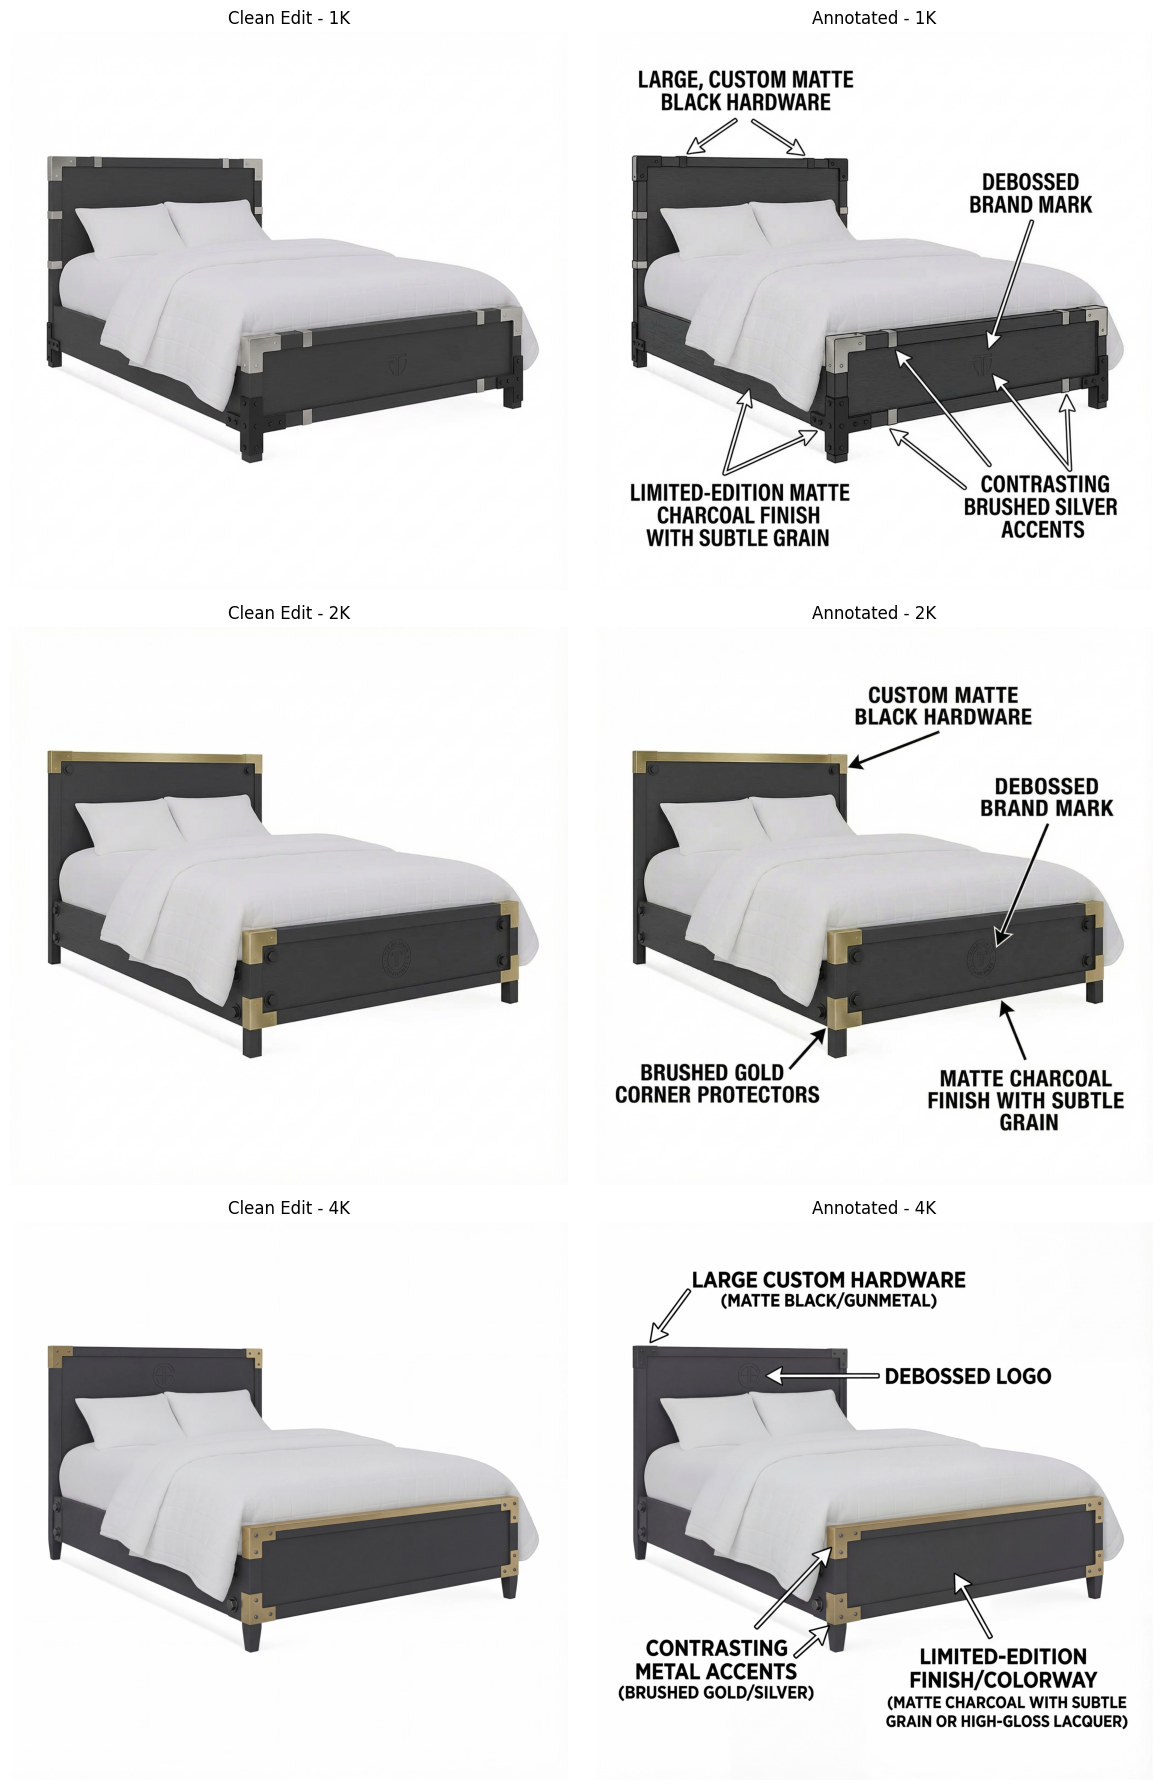

In [ ]:
print(f"\n Summary Title: {summary_title} ###")
df = pd.DataFrame(comparison_data)
print(df.to_markdown(index=False))

# Visual Comparison Grid
fig, axes = plt.subplots(len(all_images), 2, figsize=(12, 6 * len(all_images)))
for i, (c_img, a_img, lbl) in enumerate(all_images):
    if c_img:
        axes[i, 0].imshow(c_img)
        axes[i, 0].set_title(f"Clean Edit - {lbl}")
    if a_img:
        axes[i, 1].imshow(a_img)
        axes[i, 1].set_title(f"Annotated - {lbl}")
    axes[i, 0].axis('off')
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()